<a href="https://colab.research.google.com/github/THARUNIKA28/Elevator-fault-detection-system/blob/main/Elevator_Fault_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gradio scikit-learn pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 6.5 MB/s eta 0:00:00


In [4]:
df.to_csv("elevator_data.csv", index=False)
from google.colab import files
files.download("elevator_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

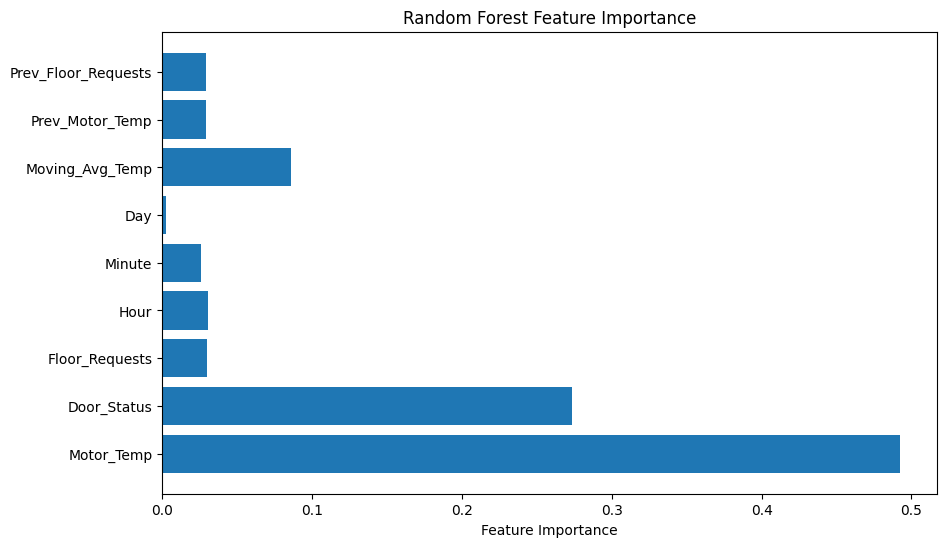

In [5]:
import matplotlib.pyplot as plt

# Get feature importance from the best model
feature_importances = best_rf.feature_importances_
features = X.columns

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()


In [6]:
pip install imbalanced-learn


In [7]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("Class distribution before SMOTE:", y_train.value_counts())
print("Class distribution after SMOTE:", y_train_res.value_counts())


Class distribution before SMOTE: Fault_Flag
1    86
0    70
Name: count, dtype: int64
Class distribution after SMOTE: Fault_Flag
1    86
0    86
Name: count, dtype: int64


In [9]:
import pandas as pd
import random
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Generate mock elevator data
def generate_elevator_data(rows=200):
    data = []
    base_time = datetime.now()

    for i in range(rows):
        timestamp = base_time + timedelta(minutes=5*i)
        elevator_id = f"E{random.randint(1, 5)}"
        motor_temp = random.randint(70, 110)
        door_status = random.choice(["Closed", "Open", "Stuck"])
        floor_requests = random.randint(1, 10)

        # Introduce some noise (5% chance to flip the correct label)
        if motor_temp > 95 or door_status == "Stuck":
            fault_flag = 1 if random.random() > 0.05 else 0
        else:
            fault_flag = 0 if random.random() > 0.05 else 1

        data.append([timestamp, elevator_id, motor_temp, door_status, floor_requests, fault_flag])

    df = pd.DataFrame(data, columns=["Timestamp", "Elevator_ID", "Motor_Temp", "Door_Status", "Floor_Requests", "Fault_Flag"])
    return df

# Create and preview dataset
df = generate_elevator_data()

# Feature engineering: Add time-related features and moving averages
df['Hour'] = df['Timestamp'].dt.hour
df['Minute'] = df['Timestamp'].dt.minute
df['Day'] = df['Timestamp'].dt.dayofweek
df['Moving_Avg_Temp'] = df['Motor_Temp'].rolling(window=5).mean()

# Handle categorical variables: Convert 'Door_Status' to numeric
le = LabelEncoder()
df['Door_Status'] = le.fit_transform(df['Door_Status'])

# Lag features: Previous 'Motor_Temp' and 'Floor_Requests'
df['Prev_Motor_Temp'] = df['Motor_Temp'].shift(1)
df['Prev_Floor_Requests'] = df['Floor_Requests'].shift(1)

# Drop rows with NaN values generated by rolling mean and lag
df.dropna(inplace=True)

# Define features and target
X = df[['Motor_Temp', 'Door_Status', 'Floor_Requests', 'Hour', 'Minute', 'Day', 'Moving_Avg_Temp', 'Prev_Motor_Temp', 'Prev_Floor_Requests']]
y = df['Fault_Flag']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model: Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Train the model with the balanced dataset
best_rf.fit(X_train_res, y_train_res)

# Make predictions on the test set
y_pred_resampled = best_rf.predict(X_test)

# Evaluate the model again
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
precision_resampled = precision_score(y_test, y_pred_resampled)
recall_resampled = recall_score(y_test, y_pred_resampled)
f1_resampled = f1_score(y_test, y_pred_resampled)
cm_resampled = confusion_matrix(y_test, y_pred_resampled)

# Display results after SMOTE
print("Accuracy after SMOTE:", accuracy_resampled)
print("Precision after SMOTE:", precision_resampled)
print("Recall after SMOTE:", recall_resampled)
print("F1-Score after SMOTE:", f1_resampled)
print("Confusion Matrix after SMOTE:\n", cm_resampled)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Accuracy after SMOTE: 1.0
Precision after SMOTE: 1.0
Recall after SMOTE: 1.0
F1-Score after SMOTE: 1.0
Confusion Matrix after SMOTE:
 [[22  0]
 [ 0 18]]


In [10]:
import gradio as gr

# Use the best estimator from grid search
best_rf = grid_search.best_estimator_

# Gradio prediction function
def predict_fault(motor_temp, door_status, floor_requests, hour, minute, day,
                  prev_motor_temp, prev_floor_requests, moving_avg_temp):
    # Encode door status
    door_status_encoded = le.transform([door_status])[0]

    # Prepare input
    input_data = [[motor_temp, door_status_encoded, floor_requests, hour, minute, day,
                   moving_avg_temp, prev_motor_temp, prev_floor_requests]]

    # Predict
    prediction = best_rf.predict(input_data)[0]
    if prediction == 1:
        return "⚠️ Fault Detected in Elevator!"
    else:
        return "✅ Elevator is Functioning Normally."

# Gradio Interface
interface = gr.Interface(
    fn=predict_fault,
    inputs=[
        gr.Number(label="Motor Temperature (°C)"),
        gr.Radio(["Closed", "Open", "Stuck"], label="Door Status"),
        gr.Slider(1, 10, step=1, label="Floor Requests (past 10 min)"),
        gr.Slider(0, 23, step=1, label="Hour of the Day"),
        gr.Slider(0, 59, step=1, label="Minute"),
        gr.Slider(0, 6, step=1, label="Day of Week (0=Mon)"),
        gr.Number(label="Moving Avg Temp (°C)"),
        gr.Number(label="Previous Motor Temp (°C)"),
        gr.Slider(1, 10, step=1, label="Previous Floor Requests")
    ],
    outputs="text",
    title="Elevator Fault Detection System",
    description="Enter elevator parameters to predict fault using ML model."
)

# Launch the app
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://453bcf92cdba5e2e51.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
!pip install --upgrade gradio
